# Simulated Annealing - Parameters Analysis

In this notebook we will test different combinations of parameters for the simulated annealing algorithm on QUBO instances.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import time
import random

from Problem.QuboProblem import QuboProblem
from Algorithm.Classical_Algorithm.Simulated_annealing import simulated_annealing
from Algorithm.Classical_Algorithm.Exhaustive_search import exhaustive_search

## Create a QUBO instance big enough to challenge SA

We create a random QUBO matrix of size 20x20. This is big enough that the SA might not always converge to the optimal.

In [2]:
# Create a random QUBO instance of size 20
np.random.seed(42)
n = 20
# Generate a random upper triangular matrix
Q = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        Q[i][j] = np.random.uniform(-5, 5)

qubo_big = QuboProblem(Q)
print(f"QUBO matrix size: {n}x{n}")
print(f"Number of possible solutions: 2^{n} = {2**n}")

QUBO matrix size: 20x20
Number of possible solutions: 2^20 = 1048576


## Study convergence by running SA multiple times

We run SA 20 times with the same parameters and look at the variations in results.

Mean cost: -102.0822
Std deviation: 0.0000
Min cost: -102.0822
Max cost: -102.0822


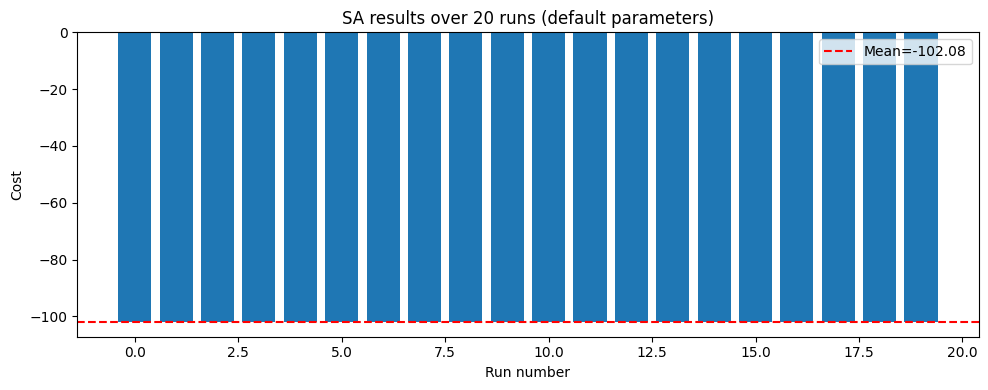

In [3]:
# Run SA 20 times with default parameters
n_runs = 20
results_default = []

for i in range(n_runs):
    best, cost = simulated_annealing(qubo_big, initial_temperature=100.0,
                                      decreasing_factor=0.95, steps_per_temp=10,
                                      temp_threshold=0.01)
    results_default.append(cost)

print(f"Mean cost: {np.mean(results_default):.4f}")
print(f"Std deviation: {np.std(results_default):.4f}")
print(f"Min cost: {np.min(results_default):.4f}")
print(f"Max cost: {np.max(results_default):.4f}")

plt.figure(figsize=(10, 4))
plt.bar(range(n_runs), results_default)
plt.xlabel('Run number')
plt.ylabel('Cost')
plt.title('SA results over 20 runs (default parameters)')
plt.axhline(y=np.mean(results_default), color='r', linestyle='--', label=f'Mean={np.mean(results_default):.2f}')
plt.legend()
plt.tight_layout()
plt.show()

## Test different initial temperatures

In [4]:
temperatures = [10, 50, 100, 500, 1000, 5000]
results_by_temp = {}
times_by_temp = {}

for temp in temperatures:
    costs = []
    elapsed_times = []
    for run in range(10):
        start = time.time()
        best, cost = simulated_annealing(qubo_big, initial_temperature=temp,
                                          decreasing_factor=0.95, steps_per_temp=10,
                                          temp_threshold=0.01)
        elapsed = time.time() - start
        costs.append(cost)
        elapsed_times.append(elapsed)
    results_by_temp[temp] = costs
    times_by_temp[temp] = elapsed_times
    print(f"T0={temp} : mean_cost={np.mean(costs):.2f}, std={np.std(costs):.2f}, mean_time={np.mean(elapsed_times):.4f}s")

T0=10 : mean_cost=-102.08, std=0.00, mean_time=0.0098s
T0=50 : mean_cost=-102.08, std=0.00, mean_time=0.0133s


T0=100 : mean_cost=-102.08, std=0.00, mean_time=0.0139s
T0=500 : mean_cost=-102.08, std=0.00, mean_time=0.0155s


T0=1000 : mean_cost=-102.08, std=0.00, mean_time=0.0168s
T0=5000 : mean_cost=-102.08, std=0.00, mean_time=0.0185s


C:\Users\Thomas\AppData\Local\Temp\ipykernel_16368\3779156240.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([results_by_temp[t] for t in temperatures], labels=[str(t) for t in temperatures])


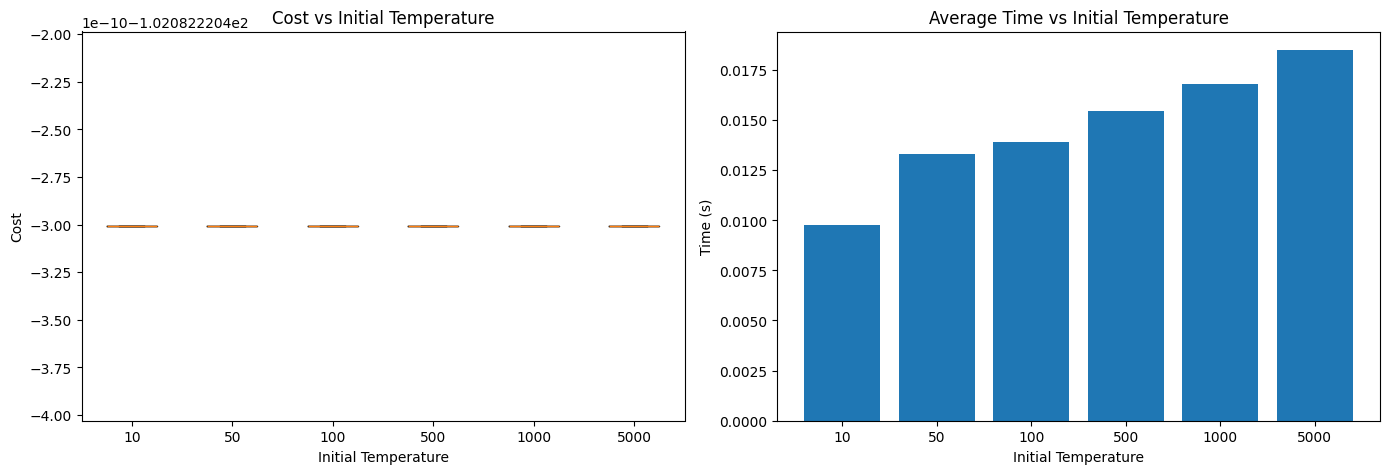

In [5]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of costs
axes[0].boxplot([results_by_temp[t] for t in temperatures], labels=[str(t) for t in temperatures])
axes[0].set_xlabel('Initial Temperature')
axes[0].set_ylabel('Cost')
axes[0].set_title('Cost vs Initial Temperature')

# Average time
avg_times = [np.mean(times_by_temp[t]) for t in temperatures]
axes[1].bar([str(t) for t in temperatures], avg_times)
axes[1].set_xlabel('Initial Temperature')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Average Time vs Initial Temperature')

plt.tight_layout()
plt.show()

## Test different cooling schedules

exponential : mean=-102.08, std=0.00
linear : mean=-68.90, std=13.78
geometric : mean=-102.08, std=0.00


C:\Users\Thomas\AppData\Local\Temp\ipykernel_16368\1236845830.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([results_by_schedule[s] for s in schedules], labels=schedules)


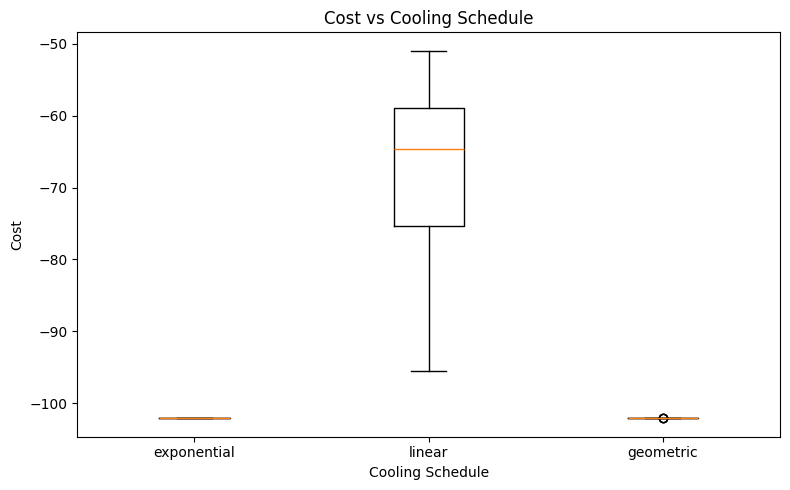

In [6]:
schedules = ["exponential", "linear", "geometric"]
results_by_schedule = {}

for schedule in schedules:
    costs = []
    for run in range(10):
        best, cost = simulated_annealing(qubo_big, initial_temperature=100.0,
                                          decreasing_factor=0.95, steps_per_temp=10,
                                          temp_threshold=0.01,
                                          cooling_schedule=schedule)
        costs.append(cost)
    results_by_schedule[schedule] = costs
    print(f"{schedule} : mean={np.mean(costs):.2f}, std={np.std(costs):.2f}")

plt.figure(figsize=(8, 5))
plt.boxplot([results_by_schedule[s] for s in schedules], labels=schedules)
plt.xlabel('Cooling Schedule')
plt.ylabel('Cost')
plt.title('Cost vs Cooling Schedule')
plt.tight_layout()
plt.show()

## Test different decreasing factors

In [7]:
factors = [0.8, 0.85, 0.9, 0.95, 0.99, 0.995]
results_by_factor = {}
times_by_factor = {}

for factor in factors:
    costs = []
    elapsed_times = []
    for run in range(10):
        start = time.time()
        best, cost = simulated_annealing(qubo_big, initial_temperature=100.0,
                                          decreasing_factor=factor, steps_per_temp=10,
                                          temp_threshold=0.01)
        elapsed = time.time() - start
        costs.append(cost)
        elapsed_times.append(elapsed)
    results_by_factor[factor] = costs
    times_by_factor[factor] = elapsed_times
    print(f"alpha={factor}: mean_cost={np.mean(costs):.2f}, std={np.std(costs):.2f}, time={np.mean(elapsed_times):.4f}s")

alpha=0.8: mean_cost=-101.72, std=0.72, time=0.0031s
alpha=0.85: mean_cost=-101.90, std=0.54, time=0.0043s
alpha=0.9: mean_cost=-101.90, std=0.54, time=0.0066s


alpha=0.95: mean_cost=-102.08, std=0.00, time=0.0132s


alpha=0.99: mean_cost=-102.08, std=0.00, time=0.0674s


alpha=0.995: mean_cost=-102.08, std=0.00, time=0.1344s


C:\Users\Thomas\AppData\Local\Temp\ipykernel_16368\906059262.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([results_by_factor[f] for f in factors], labels=[str(f) for f in factors])


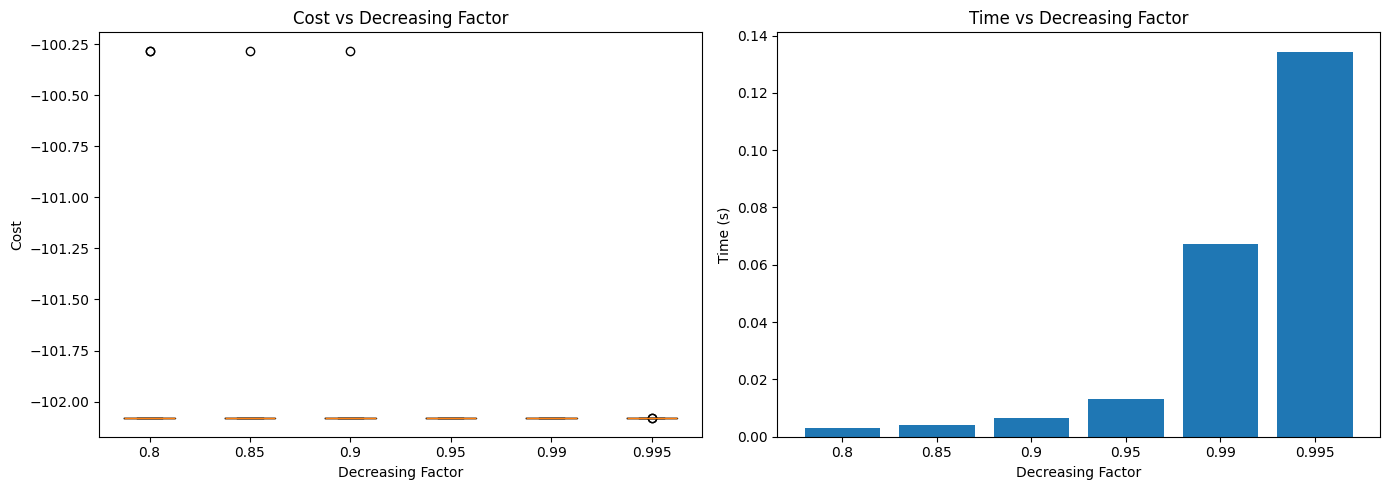

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([results_by_factor[f] for f in factors], labels=[str(f) for f in factors])
axes[0].set_xlabel('Decreasing Factor')
axes[0].set_ylabel('Cost')
axes[0].set_title('Cost vs Decreasing Factor')

avg_times_f = [np.mean(times_by_factor[f]) for f in factors]
axes[1].bar([str(f) for f in factors], avg_times_f)
axes[1].set_xlabel('Decreasing Factor')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Time vs Decreasing Factor')

plt.tight_layout()
plt.show()

## Test different steps per temperature

steps=1 : mean=-101.90, std=0.54


steps=5 : mean=-102.08, std=0.00
steps=10 : mean=-102.08, std=0.00


steps=20 : mean=-102.08, std=0.00


steps=50 : mean=-102.08, std=0.00


steps=100 : mean=-102.08, std=0.00


C:\Users\Thomas\AppData\Local\Temp\ipykernel_16368\2586426058.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([results_by_steps[s] for s in steps_list], labels=[str(s) for s in steps_list])


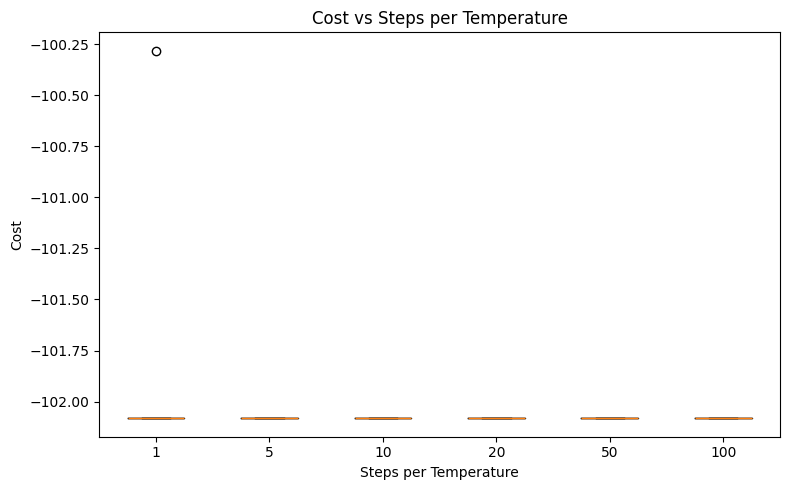

In [9]:
steps_list = [1, 5, 10, 20, 50, 100]
results_by_steps = {}

for steps in steps_list:
    costs = []
    for run in range(10):
        best, cost = simulated_annealing(qubo_big, initial_temperature=100.0,
                                          decreasing_factor=0.95, steps_per_temp=steps,
                                          temp_threshold=0.01)
        costs.append(cost)
    results_by_steps[steps] = costs
    print(f"steps={steps} : mean={np.mean(costs):.2f}, std={np.std(costs):.2f}")

plt.figure(figsize=(8, 5))
plt.boxplot([results_by_steps[s] for s in steps_list], labels=[str(s) for s in steps_list])
plt.xlabel('Steps per Temperature')
plt.ylabel('Cost')
plt.title('Cost vs Steps per Temperature')
plt.tight_layout()
plt.show()

## Critical Analysis

Based on our experiments:

1. **Initial Temperature**: A higher initial temperature allows the algorithm to explore more of the solution space early on, which helps avoid getting stuck in local minima. However, too high a temperature wastes time accepting bad solutions. We found that T0=100-500 works well for our instance.

2. **Cooling Schedule**: Exponential and geometric schedules give similar results (they are mathematically equivalent: T_{k+1} = alpha * T_k). Linear cooling tends to cool too fast at the beginning and too slow at the end. The exponential schedule is the most commonly used in practice (Kirkpatrick et al., 1983).

3. **Decreasing Factor**: A factor closer to 1 (e.g., 0.99) gives better results because the temperature decreases more slowly, allowing more exploration. However, it also takes more time. There is a tradeoff between solution quality and computation time. A common rule of thumb is to use alpha between 0.9 and 0.99 (Eglese, 1990).

4. **Steps per Temperature**: More steps per temperature level allow the algorithm to better explore the neighborhood at each temperature. With too few steps, the algorithm doesn't have enough time to equilibrate. A good rule of thumb is to set the number of steps proportional to the problem size n (Ben-Ameur, 2004).

**References:**
- Kirkpatrick, S., Gelatt, C. D., & Vecchi, M. P. (1983). Optimization by simulated annealing. Science, 220(4598), 671-680.
- Eglese, R. W. (1990). Simulated annealing: A tool for operational research. European Journal of Operational Research, 46(3), 271-281.
- Ben-Ameur, W. (2004). Computing the initial temperature of simulated annealing. Computational Optimization and Applications, 29(3), 369-385.